In [1]:
import numpy as np
import math 
import torch
import nibabel as nib
import matplotlib.pyplot as plt

# Simulator

In [2]:
class ball_and_sticks_SSFP:
    """
    Ball&Sticks dMRI model to simulate the signal attenuation S/S0 in SSFP data.
    It assumes noise-free signal generation (i.e., no SNR is passed as a parameter).

    ## Fix the order in params as it is more convenient for you - Right now it assumes params = [bs_params, FixP, CFP]

    ---------------------------------------------
    Assumed Units for Input Parameters:
    ---------------------------------------------
    T1              : longitudinal relaxation time (ms)
    T2              : transverse relaxation time (ms)
    B1              : relative transmit scaling factor (unitless)

    TR              : repetition time (s)
    flipAngles      : degrees 
    diffGradAmps    : strength of diffusion gradient (mT/m)
    diffGradDur     : duration of diffusion gradient (ms)
    ---------------------------------------------
    """
    def __init__(self, T1, T2, B1, TRs, diffGradAmps, diffGradDur, flipAngles, noisefloor):
        dataFolder = '/Users/mszjm2/Downloads/SBI/New_projects/SSFP/Full_brain/'

        # CFP
        self.T1 = T1 * 10**-3                        # Convert ms to seconds
        self.T2 = T2 * 10**-3                        # Convert ms to seconds
        self.B1 = B1              
        # FixP
        self.gyro = 4258*2*np.pi                     # Hz/G -> =26.7513e3 
        self.TRs = TRs                               
        self.flipAngles = flipAngles * np.pi/180     # Convert degrees to radians
        self.diffGradAmps = diffGradAmps * 10**-1    # Convert to G/mm
        self.diffGradDur = diffGradDur
        self.noisefloor = noisefloor
        self.bvecs = np.genfromtxt(dataFolder + 'bvecs', dtype=np.float32)  # => Adapt it to your way of passing bvecs
        

    def project_fiber(self, theta, phi): 
        return (
            self.bvecs[0] * np.sin(theta) * np.cos(phi) +
            self.bvecs[1] * np.sin(theta) * np.sin(phi) +
            self.bvecs[2] * np.cos(theta)
            )
    
    def SSFP_Signal(self, S0, adc): # SSFP signal generation
        single_shell = True

        # Relaxation terms
        E1 = np.exp(-self.TRs / self.T1)  
        E2 = np.exp(-self.TRs / self.T2)  

        # Flipping terms
        sa = np.sin(self.flipAngles * self.B1)
        ca = np.cos(self.flipAngles * self.B1)

        if single_shell:

            qval = self.gyro * self.diffGradAmps * self.diffGradDur 

            A1 = np.exp(-qval**2 * self.TRs * adc)
            A2 = np.exp(-qval**2 * self.diffGradDur * adc)
            A2_03 = np.exp(-qval**2 * self.diffGradDur * adc / 3.0)

            s = E2 * A1 / A2_03**4 * (1.0 - E1 * ca) + E2 / A2_03 * (ca - E1)
            r = 1.0 - E1 * ca + E2**2 * A1 * A2_03 * (ca - E1)
            K = (
                (1.0 - E1 * A1 * ca - E2**2 * A1**2 / A2_03**2 * (E1 * A1 - ca)) /
                (E2 * A1 / A2_03**4 * (1.0 + ca) * (1.0 - E1 * A1))
            )

            F1 = K - np.sqrt(K**2 - A2**2)
            Mminus_top = -(1.0 - E1) * E2 / A2_03**2 * (F1 - E2 * A1 * A2_03**2) * sa
            Mminus_bottom = r - F1 * s
            #signal = np.sqrt(np.abs(S0 * Mminus_top / Mminus_bottom)**2 + self.noisefloor**2)
            signal = np.sqrt(np.abs(S0 * Mminus_top / Mminus_bottom)**2)
        else:
            pass

        return signal


    def __call__(self, bs_params): # Ball&Sticks forward model based on SSFP signal generation
        S0 = 1#bs_params[-1] # It seems the normalisation is a bit tricky...
        adc = bs_params[0]  # Shared ADC across all components

        # Isotropic term (ball) 
        isoterm = self.SSFP_Signal(S0, adc)
        pred_signal = (1 - bs_params[1] - bs_params[4] - bs_params[7]) * isoterm

        # Anisotropic terms (sticks)
        for i in [1, 4, 7]:
            theta, phi = bs_params[i + 1], bs_params[i + 2]
            xv = self.project_fiber(theta, phi)
            adc_aniso = adc * xv**2
            anisoterm = self.SSFP_Signal(S0, adc_aniso)
            pred_signal += bs_params[i] * anisoterm

        return pred_signal 

In [3]:
# Implementation based on Freed et al: Steady-state free precession experiments and exact treatment of diffusion in a uniform gradient J. Chem. Phys. 115, 4249 (2001); https://doi.org/10.1063/1.1389859
class ball_and_sticks_FreedSSFP:
    """
    Ball & Sticks model for diffusion-weighted SSFP signal simulation using Freed et al. (2001) formulation.
    
    Supports multiple gradient directions (bvecs) and assumes noiseless signal generation.
    """

    def __init__(self, T1, T2, B1, TRs, diffGradAmps, diffGradDur, flipAngles, noisefloor):
        dataFolder = '/Users/mszjm2/Downloads/SBI/New_projects/SSFP/Full_brain/'

        # CFP
        self.T1 = T1 * 10**-3                        # Convert ms to seconds
        self.T2 = T2 * 10**-3                        # Convert ms to seconds
        self.B1 = B1              
        # FixP
        self.gyro = 4258 * 2*np.pi                     # Hz/G -> =26.7513e3 
        self.TRs = TRs                               
        self.flipAngles = flipAngles * np.pi/180     # Convert degrees to radians
        self.diffGradAmps = diffGradAmps * 10**-1    # Convert to G/mm
        self.diffGradDur = diffGradDur
        self.noisefloor = noisefloor
        self.bvecs = np.genfromtxt(dataFolder + 'bvecs', dtype=np.float32)  # Ensure shape (3, N)

    
    def project_fiber(self, theta, phi): 
        return (
            self.bvecs[0] * np.sin(theta) * np.cos(phi) +
            self.bvecs[1] * np.sin(theta) * np.sin(phi) +
            self.bvecs[2] * np.cos(theta)
            )

    def FreedDWSSFP(self, adc):
        cosa = np.cos(self.flipAngles)
        sina = np.sin(self.flipAngles)

        def E1p(p): return np.exp(-self.TRs / self.T1 - adc * self.gyro**2 * self.diffGradAmps**2 * self.diffGradDur**2 * self.TRs * p**2)
        def E2p(p): return np.exp(-self.TRs / self.T2 - adc * self.gyro**2 * self.diffGradAmps**2 * self.diffGradDur**2 * ((p**2 + p + 1/3) * self.diffGradDur + (p + 1)**2 * (self.TRs - self.diffGradDur)))
        def Ap(p): return 0.5 * (E1p(p) - 1) * (1 + cosa)
        def Bp(p): return 0.5 * (E1p(p) + 1) * (1 - cosa)
        def Cp(p): return E1p(p) - cosa
        def np_(p): return -E2p(-p) * E2p(p - 1) * Ap(p)**2 * Bp(p - 1) / Bp(p)
        def dp(p): return (Ap(p) - Bp(p)) + E2p(-p - 1) * E2p(p) * Bp(p) * Cp(p + 1) / Bp(p + 1)
        def ep(p): return -E2p(p) * E2p(-p - 1) * Bp(p) * Cp(p + 1) / Bp(p + 1)

        x1 = 0
        for k in range(10,0,-1):
            if k==1000:
                x1=np_(k)/(dp(k)+ep(k))
            else:
                x1=np_(k)/(dp(k)+x1)

        r1 = x1 / (E2p(-1) * Bp(0)) + (E2p(0) * Cp(1)) / Bp(1)
        S = r1 * sina * (1 - E1p(0)) * E2p(-1) / (Ap(0) - Bp(0) + E2p(-1) * Cp(0) * r1)

        return np.abs(S)

    def __call__(self, bs_params):
        S0 = 1#bs_params[-1]
        adc = bs_params[0]
        
        # Isotropic term (ball)        
        isoterm = self.FreedDWSSFP(adc)
        pred = (1 - bs_params[1] - bs_params[4] - bs_params[7]) * isoterm

        # Anisotropic terms (sticks)
        for i in [1, 4, 7]:
            theta, phi = bs_params[i + 1], bs_params[i + 2]
            xv = self.project_fiber(theta, phi)
            adc_aniso = adc * xv**2
            anisoterm = self.FreedDWSSFP(adc_aniso)
            pred += bs_params[i] * anisoterm

        pred *= S0  # Scale by S0
        return pred

# Try on actual data

In [6]:
# Auxiliary functions
def get_data(file, mmap=True):
    """
    Load NIfTI image data from a file.

    Parameters:
        file (str): The path to the NIfTI file.
        mmap (bool, optional): Whether to use memory-mapped file access. Default is True.

    Returns:
        numpy.ndarray: The voxel data from the NIfTI file.
    """
    img = nib.load(file, mmap=mmap)
    img_voxels = img.get_fdata()
    return img_voxels


def cart2sph(x,y,z):
  #takes list xyz (single coord)
  r       =  np.sqrt(x*x + y*y + z*z)
  if r==0:
    theta = math.acos(z / 1)    # To avoid NaN when r==0
  else:
    theta = math.acos(z/r) 

  phi = math.atan2(y,x)  
  return theta, phi


In [7]:
dPath = '/Users/mszjm2/Downloads/SBI/New_projects/SSFP/Full_brain'  # => Change it to your path
x,y,z = 161,170,71

# Brain data
signal = get_data(f'{dPath}/data.nii.gz')[x,y,z]#[10] # Convert to numpy array

# Load acquisition and tissue parameters
TRs = np.loadtxt(f'{dPath}/TRs')
flipangles = np.loadtxt(f'{dPath}/flipAngles')
diffGradAmps = np.loadtxt(f'{dPath}/diffGradAmps')
diffGradDur = np.loadtxt(f'{dPath}/diffGradDurs')
T1 = nib.load(f'{dPath}/T1.nii.gz').get_fdata()[x,y,z]
T2 = nib.load(f'{dPath}/T2.nii.gz').get_fdata()[x,y,z]
B1 = nib.load(f'{dPath}/B1.nii.gz').get_fdata()[x,y,z]
bvals = np.loadtxt(f'{dPath}/bvals')
noisefloor = np.loadtxt(f'{dPath}/noisefloor')

# Load Ball&sticks params from MCMC estimates on that data
d = get_data(f'{dPath}/data.Ball_3_Sticks_1Shell_SSFP_bpx/mean_dsamples.nii.gz')[x,y,z]
f1 = get_data(f'{dPath}/data.Ball_3_Sticks_1Shell_SSFP_bpx/mean_f1samples.nii.gz')[x,y,z]
v1 = get_data(f'{dPath}/data.Ball_3_Sticks_1Shell_SSFP_bpx/dyads1.nii.gz')[x,y,z]
th1, ph1 = cart2sph(v1[0],v1[1],v1[2])
f2 = get_data(f'{dPath}/data.Ball_3_Sticks_1Shell_SSFP_bpx/mean_f2samples.nii.gz')[x,y,z]
v2 = get_data(f'{dPath}/data.Ball_3_Sticks_1Shell_SSFP_bpx/dyads2.nii.gz')[x,y,z]
th2, ph2 = cart2sph(v2[0],v2[1],v2[2])
f3 = get_data(f'{dPath}/data.Ball_3_Sticks_1Shell_SSFP_bpx/mean_f3samples.nii.gz')[x,y,z]
v3 = get_data(f'{dPath}/data.Ball_3_Sticks_1Shell_SSFP_bpx/dyads3.nii.gz')[x,y,z]
th3, ph3 = cart2sph(v3[0],v3[1],v3[2])
S0 = get_data(f'{dPath}/data.Ball_3_Sticks_1Shell_SSFP_bpx/mean_S0samples.nii.gz')[x,y,z]
bs_params = torch.tensor([d, f1, th1, ph1, f2, th2, ph2, f3, th3, ph3, S0]).detach().numpy()

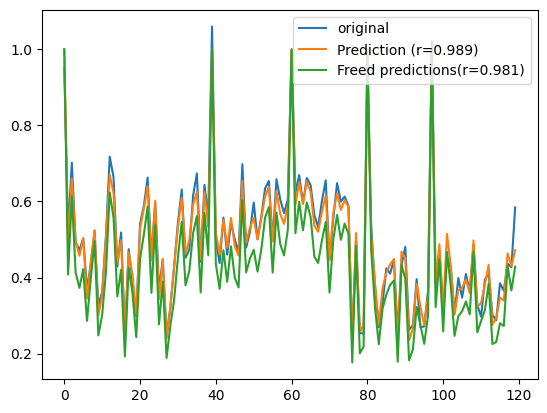

In [12]:
# Normalise brain data
b0 = bvals == 0
s0 = signal[...,b0].mean(-1, keepdims=True)
signal_norm = signal/s0

# Forward prediction using MCMC estimates
simulator = ball_and_sticks_SSFP(T1=T1, T2=T2, B1=B1, TRs=TRs, diffGradAmps=diffGradAmps, diffGradDur=diffGradDur, flipAngles=flipangles, noisefloor=noisefloor)
signal_pred = simulator(bs_params)
signal_pred = signal_pred / np.max(signal_pred)  # Normalise prediction ==
r_pred = np.round(np.corrcoef(signal_norm, signal_pred)[0, 1],3)

# Forward prediction using MCMC estimates and Freed et al. (2001) formulation
simulator_Freed = ball_and_sticks_FreedSSFP(T1=T1, T2=T2, B1=B1, TRs=TRs, diffGradAmps=diffGradAmps, diffGradDur=diffGradDur, flipAngles=flipangles, noisefloor=noisefloor)
signal_pred_Freed = simulator_Freed(bs_params)
signal_pred_Freed = signal_pred_Freed / np.max(signal_pred_Freed)  # Normalise prediction == 
r_Freed = np.round(np.corrcoef(signal_norm, signal_pred_Freed)[0, 1], 3)

plt.plot(signal_norm, label='original')
plt.plot(signal_pred, label=f'Prediction (r={r_pred})')
plt.plot(signal_pred_Freed, label=f'Freed predictions(r={r_Freed})')

plt.legend()
plt.show()

In [ ]:
# Priors for training:
T1 = np.random.uniform(600, 2400)  # T1 range in ms
T2 = np.random.uniform(10, 125) # T2 range in ms    # In CSF, it can go to very high random values e.g. to 500-15000
TR = np.random.uniform(5, 50)  # Repetition time in ms

# Coupled parameters//boundary conditions:
# B1 * flipAngle --> Cover anything up to 40-50 degrees
# qvalue = diffGradAmps * diffGradDur * gyro --> up to 40-50 mm-1 to cover everything

# Common values and ranges for these coupled parameters
B1 = np.random.uniform(0, 2)             # Normally it is around 0.8-1.2
flipangles = np.random.uniform(1, 50)    # Flip angles in degrees
diffGradDur = np.random.uniform(5, 20)   # Diffusion gradient duration in ms
diffGradAmps = np.random.uniform(0, 100) # Diffusion gradient amplitude in mT/m

# Others:
# noisefloor = given by the sigma of the noise distribution